In [1]:
import numpy as np
import datetime
import pandas as pd
import random

In [2]:
def data1():
    X=pd.read_csv('nifty.csv')
    # Ensure 'Open' and 'Close' are treated as numeric
    X['Open'] = pd.to_numeric(X['Open'], errors='coerce')
    X['Close'] = pd.to_numeric(X['Close'], errors='coerce')
    X['c-o']=(X.Close-X.Open)/X.Open*100
    X['candle']=np.where(X['c-o'].values<-1,0,np.where(X['c-o'].values<-0.5,1,np.where(X['c-o'].values<0,2,np.where(X['c-o'].values<0.5,3,np.where(X['c-o'].values<1,4,5)))))
    X = X.dropna(axis = 0, how ='any')
    X = X.reset_index()
    X['cashopen']=0
    X['cash']=0
    # Ensure columns have float dtype before assignment
    X['cashopen'] = X['cashopen'].astype(float)
    X['cash'] = X['cash'].astype(float)
    X['action']=""
    X['diff']=""
    X['quantity']=""
    return X
    

In [3]:
X=data1()

In [4]:
print(len(X))

2945


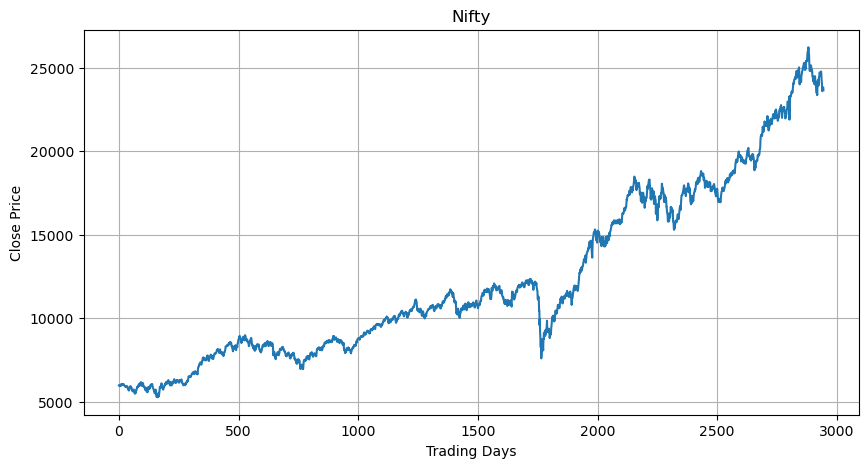

In [5]:
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure()
ax=X.loc[0:len(X),'Close'].plot(grid="True",figsize=(10,5), title='Nifty')
ax.set_xlabel("Trading Days")
ax.set_ylabel("Close Price")
plt.show()
fig.savefig('nifty_close.png')

In [6]:
X['candle'].value_counts()

candle
2    837
3    808
1    432
4    361
0    296
5    211
Name: count, dtype: int64

In [7]:
#X.head()

In [8]:
def getState(t):    
    return(X['candle'][t])  

In [9]:
class Agent:
    def __init__(self):
        self.epsilon = 1.0
        self.gamma = 0.618
        self.epsilon_decay = 0.995
        self.epsilon_min = 0.01
        self.Q = np.matrix(np.zeros([6,3]))
        self.learning_rate=0.03
        
    def getAction(self,state):
        a=[1,0,2]
        if np.random.rand() <= self.epsilon:
            return random.choice(a)
        return np.argmax(self.Q[state,])  
    
    # Update Q(s,a):= Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
    def update(self,state,action,reward,next_state,next_action):
            self.Q[state,action]= self.Q[state,action] + self.learning_rate * (reward + self.gamma * np.max(self.Q[next_state, :])
                                                                - self.Q[state,action])

        

In [10]:
episode_count=100
agent=Agent()
agent.Q
m1=0
m2=0
for e in range(1,episode_count+1):
    X=data1()
    
    data_length_start=1
    data_length=2207
    state = getState(data_length_start-1)
    action = agent.getAction(state)
    
  
    capital=X.loc[data_length_start,'Open']*10
    margin=X.loc[data_length_start,'Open']*10
    #X.loc[2,'cashopen']=margin 
    X.loc[1, 'cashopen'] = float(margin)
    brok_rate=0.0000
    #brok_rate=0.0
    
    print("Episod {}/{}".format(e,episode_count))
    count=0
    for t in range(data_length_start,data_length):
                
        reward=0                        
         
        if action == 1:
            X.loc[t,'cashopen']=float(margin)
            quantity=margin//X.loc[t,'Open']
            X.loc[t,'quantity']=quantity
            margin=margin%X.loc[t,'Open']
            tbrokerage=(X.loc[t,'Open']+X.loc[t,'Close'])*brok_rate
            tprofit=(X.loc[t,'Close']-X.loc[t,'Open']-tbrokerage)*quantity
            margin=margin+tprofit+X.loc[t,'Open']*quantity
            X.loc[t,'cash']=float(margin)         
            
            #print('Long: open price @',X.loc[t,'Open'],'Close price @',X.loc[t,'Close'], 'profit=',tprofit)
            X.loc[t,'action']="long"
            X.loc[t,'diff']=(X.loc[t,'Close']-X.loc[t,'Open']-tbrokerage)*quantity
            count=count+1
            reward= max((np.log(X.loc[t,'Close'])-np.log(X.loc[t,'Open']+tbrokerage)),0)
            
       
        elif action == 2:
            X.loc[t,'cashopen']=float(margin) 
            quantity=margin//X.loc[t,'Open']
            X.loc[t,'quantity']=(-quantity)
            margin=margin%X.loc[t,'Open']
            tbrokerage=(X.loc[t,'Open']+X.loc[t,'Close'])*brok_rate
            tprofit=(X.loc[t,'Open']-X.loc[t,'Close']-tbrokerage)*quantity
            #print('in Short')
            margin=margin+tprofit+X.loc[t,'Open']*quantity
            X.loc[t,'cash']=float(margin)         
            last_action='Short'
            #print('Short: Close price @',X.loc[t,'Close'],'Open price @',X.loc[t,'Open'], 'profit=',tprofit)
            X.loc[t,'action']="short"
            X.loc[t,'diff']=(X.loc[t,'Open']-X.loc[t,'Close']-tbrokerage)*quantity
            count=count+1
            reward= max((np.log(X.loc[t,'Open'])-np.log(X.loc[t,'Close']+tbrokerage)),0)
           
        else:
            X.loc[t,'cash']=margin
            X.loc[t,'action']="Hold"
            X.loc[t,'diff']=0
            reward=0                                  
              
        next_state=getState(t)
        next_action=agent.getAction(next_state)
        agent.update(state,action,reward,next_state,next_action)
        state=next_state
        action=next_action
        
        if t==data_length-1:
                print("\n***********************\n",t)
                print("Profit is ",(margin-capital))
                print("Initial Capital is ",capital)    
                print("Current Capital is ",margin)
                roi=((margin-capital)/capital)*100
                print("%ROI is ",roi)
                bnh=((X.loc[t,'Close']-X.loc[data_length_start,'Open'])/X.loc[data_length_start,'Open'])*100
                print("% Buy and Hold=",bnh)
                print("count",count)
                print("qtable",agent.Q)
                print("epsilon",agent.epsilon)
                print("--------------------------------")
                       
        if (agent.epsilon > agent.epsilon_min) and e>1:
                       agent.epsilon *= agent.epsilon_decay
                       
    
    m3=roi
    if m3>m2:
        m1=e
        m2=m3
    #To save model  
    if e%20==0:
        np.save('rl/Qtable'+ str(e)+str('.npy'), agent.Q)
        np.save('rl/epsilon'+ str(e)+str('.npy'), agent.epsilon)
        np.save('rl/gamma'+ str(e)+str('.npy'), agent.gamma)
        np.save('rl/learning_rate'+ str(e)+str('.npy'), agent.learning_rate)
        X.to_csv('csv1/AfterTrain'+str(e)+str('.csv'))
print("e={},roi={}".format(m1,m2))

Episod 1/100

***********************
 2206
Profit is  22259.33650200021
Initial Capital is  60157.998049999995
Current Capital is  82417.3345520002
%ROI is  37.001458199289615
% Buy and Hold= 188.47453942161235
count 1467
qtable [[0.00364886 0.00724837 0.00763661]
 [0.0036437  0.00644527 0.00723851]
 [0.00415827 0.00606229 0.00831111]
 [0.004359   0.00607956 0.00707426]
 [0.00364953 0.00561319 0.00647354]
 [0.00276086 0.00621991 0.00771135]]
epsilon 1.0
--------------------------------
Episod 2/100

***********************
 2206
Profit is  188371.415005
Initial Capital is  60157.998049999995
Current Capital is  248529.41305499998
%ROI is  313.12779864854565
% Buy and Hold= 188.47453942161235
count 2141
qtable [[0.00391513 0.00722226 0.01162906]
 [0.00405795 0.0067782  0.01017341]
 [0.00452837 0.00618273 0.00934964]
 [0.00459331 0.00614405 0.00873041]
 [0.00386579 0.00604959 0.00881531]
 [0.00316076 0.00720192 0.01105313]]
epsilon 0.00998645168764533
--------------------------------
Ep

In [11]:
agent.Q

matrix([[0.00591472, 0.00791422, 0.01170197],
        [0.00577061, 0.0070071 , 0.01027164],
        [0.00570287, 0.00677251, 0.00927434],
        [0.00584601, 0.00663046, 0.0087221 ],
        [0.00540446, 0.00762208, 0.0088594 ],
        [0.00556566, 0.00807885, 0.01112801]])

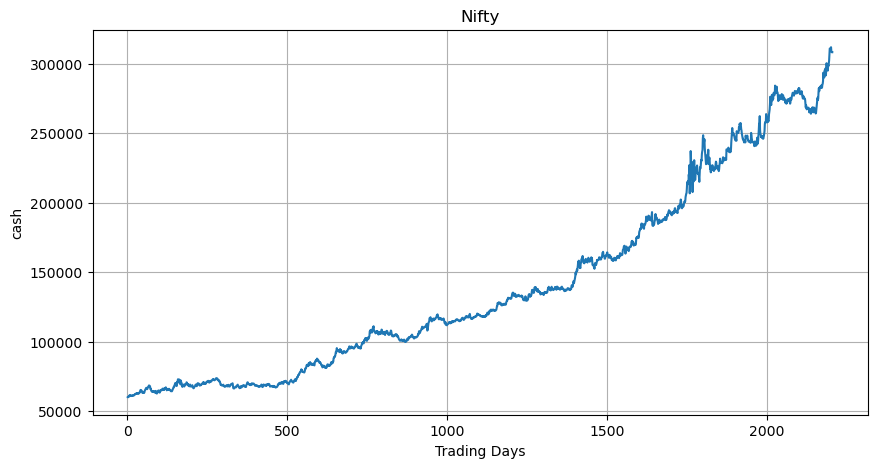

In [12]:
%matplotlib inline
fig = plt.figure()
ax=X.loc[data_length_start:data_length-2,'cash'].plot(grid="True",figsize=(10,5), title='Nifty')
ax.set_xlabel("Trading Days")
ax.set_ylabel("cash")
plt.show()